# Import libraries and data upload

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import LabelEncoder
import math

In [32]:
train = pd.read_csv(r'C:\Users\USER\OneDrive\Documents\Property_prices_predictions\train.csv')
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Data cleaning

In [33]:
train.shape

(1460, 81)

In [34]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [35]:
train.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [36]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


The dataset contains 1,460 residential property records and 81 features describing physical attributes, quality ratings, amenities, and location characteristics, along with the final sale price. There is a mix of numerical variables and categorical variables. A noticeable portion of the missing data is concentrated in features related to optional property elements such as basements, garages, masonry veneer, pools, and fences. This pattern indicates that the missingness is largely structural rather than random data loss. The descriptive statistics also show substantial variation in square footage and overall quality ratings, suggesting that the dataset captures a wide range of housing market segments—from small, lower-quality properties to large, high-end homes. This variation is essential for distinguishing price drivers in subsequent analysis.

### Missigness

In [37]:
# Missing value summary
missing_summary = (
    train.isnull().sum()
    .to_frame("Missing_Values")
    .assign(Percent=lambda df: 100 * df["Missing_Values"] / len(train))
    .query("Missing_Values > 0")
    .sort_values("Missing_Values", ascending=False)
)

missing_summary

,Missing_Values,Percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


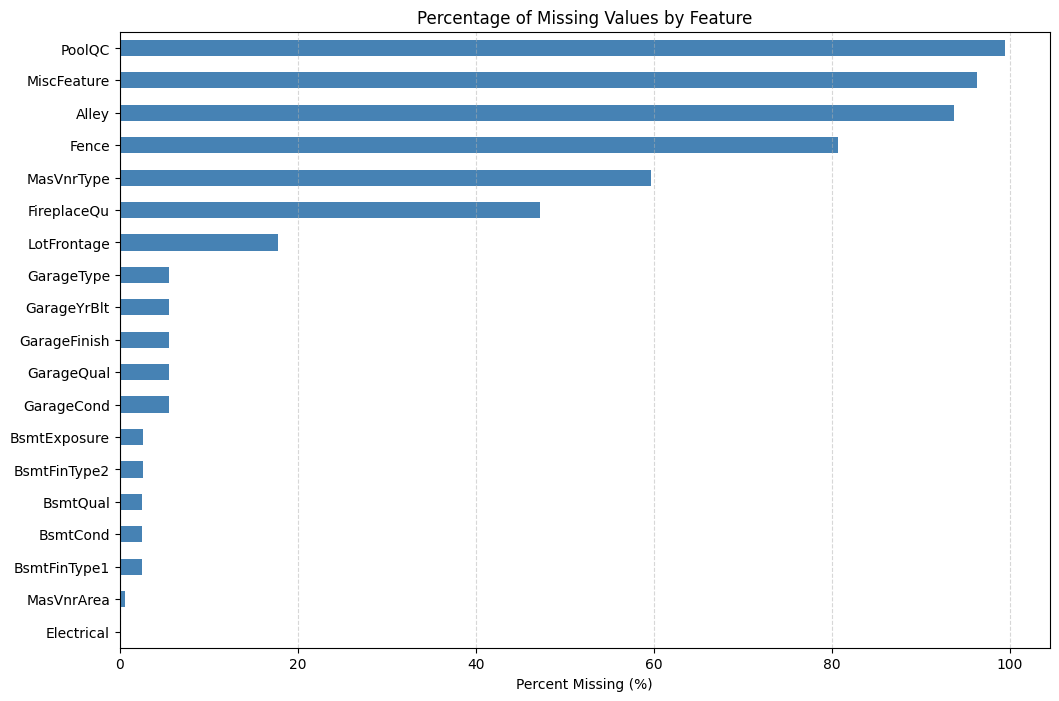

In [38]:
# missingness plot
plt.figure(figsize=(12, 8))
missing_summary["Percent"].plot(kind='barh', color='steelblue')
plt.title("Percentage of Missing Values by Feature")
plt.xlabel("Percent Missing (%)")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

In [39]:
# STRUCTURAL MISSINGNESS
none_fill_cats = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence',
    'FireplaceQu', 'GarageType', 'GarageFinish',
    'GarageQual', 'GarageCond', 'BsmtQual',
    'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
    'BsmtFinType2', 'MasVnrType'
]

for col in none_fill_cats:
    if col in train.columns:
        train[col] = train[col].fillna("None")
        print(f"Filled {col} with 'None'")

none_fill_nums = ['GarageYrBlt', 'MasVnrArea']

for col in none_fill_nums:
    if col in train.columns:
        train[col] = train[col].fillna(0)
        print(f"Filled {col} with 0")

# LOTFRONTAGE
if 'LotFrontage' in train.columns:
    train['LotFrontage'] = train.groupby("Neighborhood")["LotFrontage"].transform(
        lambda x: x.fillna(x.median())
    )

# ELECTRICAL
if 'Electrical' in train.columns:
    train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])

Filled PoolQC with 'None'
Filled MiscFeature with 'None'
Filled Alley with 'None'
Filled Fence with 'None'
Filled FireplaceQu with 'None'
Filled GarageType with 'None'
Filled GarageFinish with 'None'
Filled GarageQual with 'None'
Filled GarageCond with 'None'
Filled BsmtQual with 'None'
Filled BsmtCond with 'None'
Filled BsmtExposure with 'None'
Filled BsmtFinType1 with 'None'
Filled BsmtFinType2 with 'None'
Filled MasVnrType with 'None'
Filled GarageYrBlt with 0
Filled MasVnrArea with 0


In [40]:
# final check
print("\nRemaining Missing Values After Cleaning:")
print(train.isnull().sum().sort_values(ascending=False).head(10))


Remaining Missing Values After Cleaning:
Id             0
MSSubClass     0
MSZoning       0
LotFrontage    0
LotArea        0
Street         0
Alley          0
LotShape       0
LandContour    0
Utilities      0
dtype: int64


Structural missingness—such as no garage, no basement, no fireplace, or no pool—was filled with “None” for categorical features and 0 for numeric features because the absence represents a real-world condition, not missing data. LotFrontage was imputed using median values per neighborhood to preserve location-based patterns, while the single missing value in Electrical was filled using the mode. This approach ensured that we preserved all useful features without introducing bias or losing meaningful information.

## Duplicates

In [41]:
train.duplicated().sum()

np.int64(0)

There are no duplicate values in the dataset.

# EDA

## Univeriate

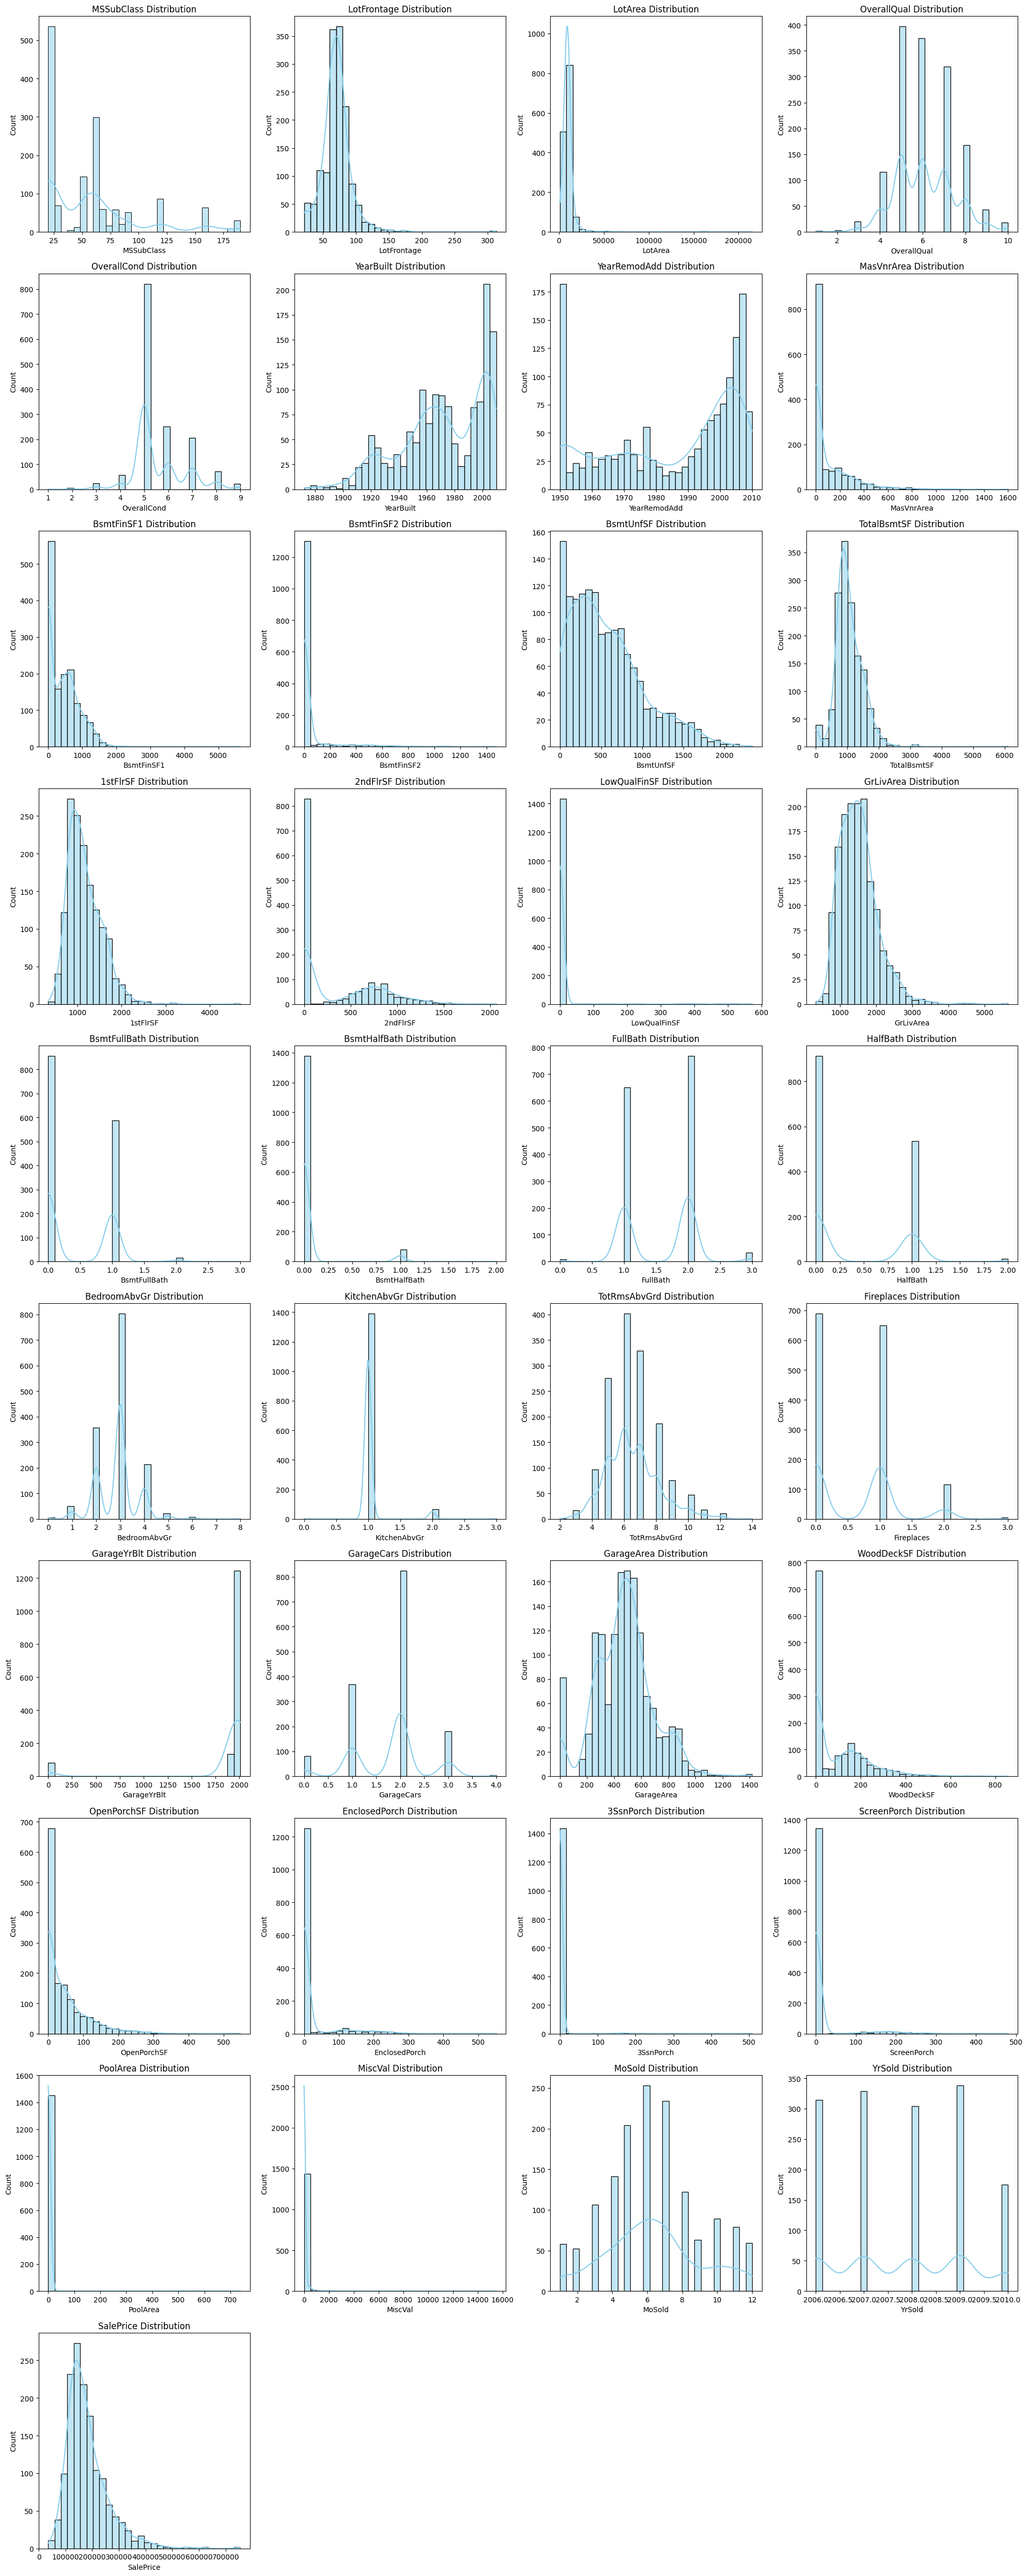

In [42]:
# numeric columns distribution
num_cols = train.select_dtypes(include=np.number).columns.tolist()
if 'Id' in num_cols:
    num_cols.remove('Id')

cols_per_row = 4
num_plots = len(num_cols)
rows = int(np.ceil(num_plots / cols_per_row))

plt.figure(figsize=(20, 5 * rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.histplot(train[col].dropna(), kde=True, bins=30, color='skyblue')
    plt.title(f'{col} Distribution')
    plt.tight_layout()

plt.show()

- Right-Skewed Distributions: LotArea, GrLivArea, TotalBsmtSF, 1stFlrSF, BsmtFinSF1, GarageArea, WoodDeckSF, OpenPorchSF, MasVnrArea, SalePrice
- Zero-Inflated: PoolArea, MiscVal, LowQualFinSF, 3SsnPorch, ScreenPorch, EnclosedPorch, BsmtFinSF2
- Normal Distributions: YearBuilt, YearRemodAdd, GarageYrBlt
- Discrete Distributions: OverallQual, OverallCond, BedroomAbvGr, KitchenAbvGr, Fireplaces, FullBath, HalfBath, BSmtFullBath, BsmtHalfBath, TotRmsAbvGrd, GarageCars
- Clustered + Right-Skewed: 2ndFlrSF, BsmtUnfSF, TotalSF, TotalPorch

In [43]:
# Check skewness and kurtosis
skew_kurt = pd.DataFrame({
    'Skewness': train[num_cols].apply(lambda x: skew(x.dropna())),
    'Kurtosis': train[num_cols].apply(lambda x: kurtosis(x.dropna()))
}).sort_values(by='Skewness', ascending=False)

skew_kurt.head(30)

,Skewness,Kurtosis
MiscVal,24.451640,698.600840
PoolArea,14.813135,222.500507
LotArea,12.195142,202.543793
3SsnPorch,10.293752,123.235177
LowQualFinSF,9.002080,82.945932
KitchenAbvGr,4.483784,21.454627
BsmtFinSF2,4.250888,20.040415
ScreenPorch,4.117977,18.371874
BsmtHalfBath,4.099186,16.336436
EnclosedPorch,3.086696,10.390972


The skewness analysis revealed that several numerical variables exhibit strong right-skewness, particularly amenities that are rare in most homes such as PoolArea, 3SsnPorch, LowQualFinSF, and MiscVal. These features are zero-inflated and are better treated as binary indicators rather than continuous measures. Additionally, size-related variables such as TotalBsmtSF, 1stFlrSF, and GrLivArea are moderately skewed due to the presence of a small number of significantly large homes.

In [44]:
# Binary conversion
binary_features = [
    'MiscVal', 'PoolArea', '3SsnPorch', 'LowQualFinSF',
    'BsmtFinSF2', 'ScreenPorch', 'BsmtHalfBath'
]

for col in binary_features:
    if col in train.columns:
        train[col] = (train[col] > 0).astype(int)
    if col in train.columns:
        train[col] = (train[col] > 0).astype(int)

# Log-transform highly skewed continuous features
log_features = [
    'LotArea', 'EnclosedPorch', 'MasVnrArea', 'OpenPorchSF',
    'LotFrontage', 'BsmtFinSF1', 'WoodDeckSF', 'TotalBsmtSF',
    '1stFlrSF', 'GrLivArea'
]

for col in log_features:
    if col in train.columns:
        train[col] = np.log1p(train[col])
    if col in train.columns:
        train[col] = np.log1p(train[col])

Skewed numerical features were handled in two ways.
- Extremely right-skewed, zero-inflated features were converted into binary indicators, since the presence of the feature matters more than its magnitude.
- For genuinely continuous, highly skewed variables such as LotArea, GrLivArea, TotalBsmtSF, and MasVnrArea, a log1p transformation was applied to reduce skewness, normalize distributions, and improve model performance.

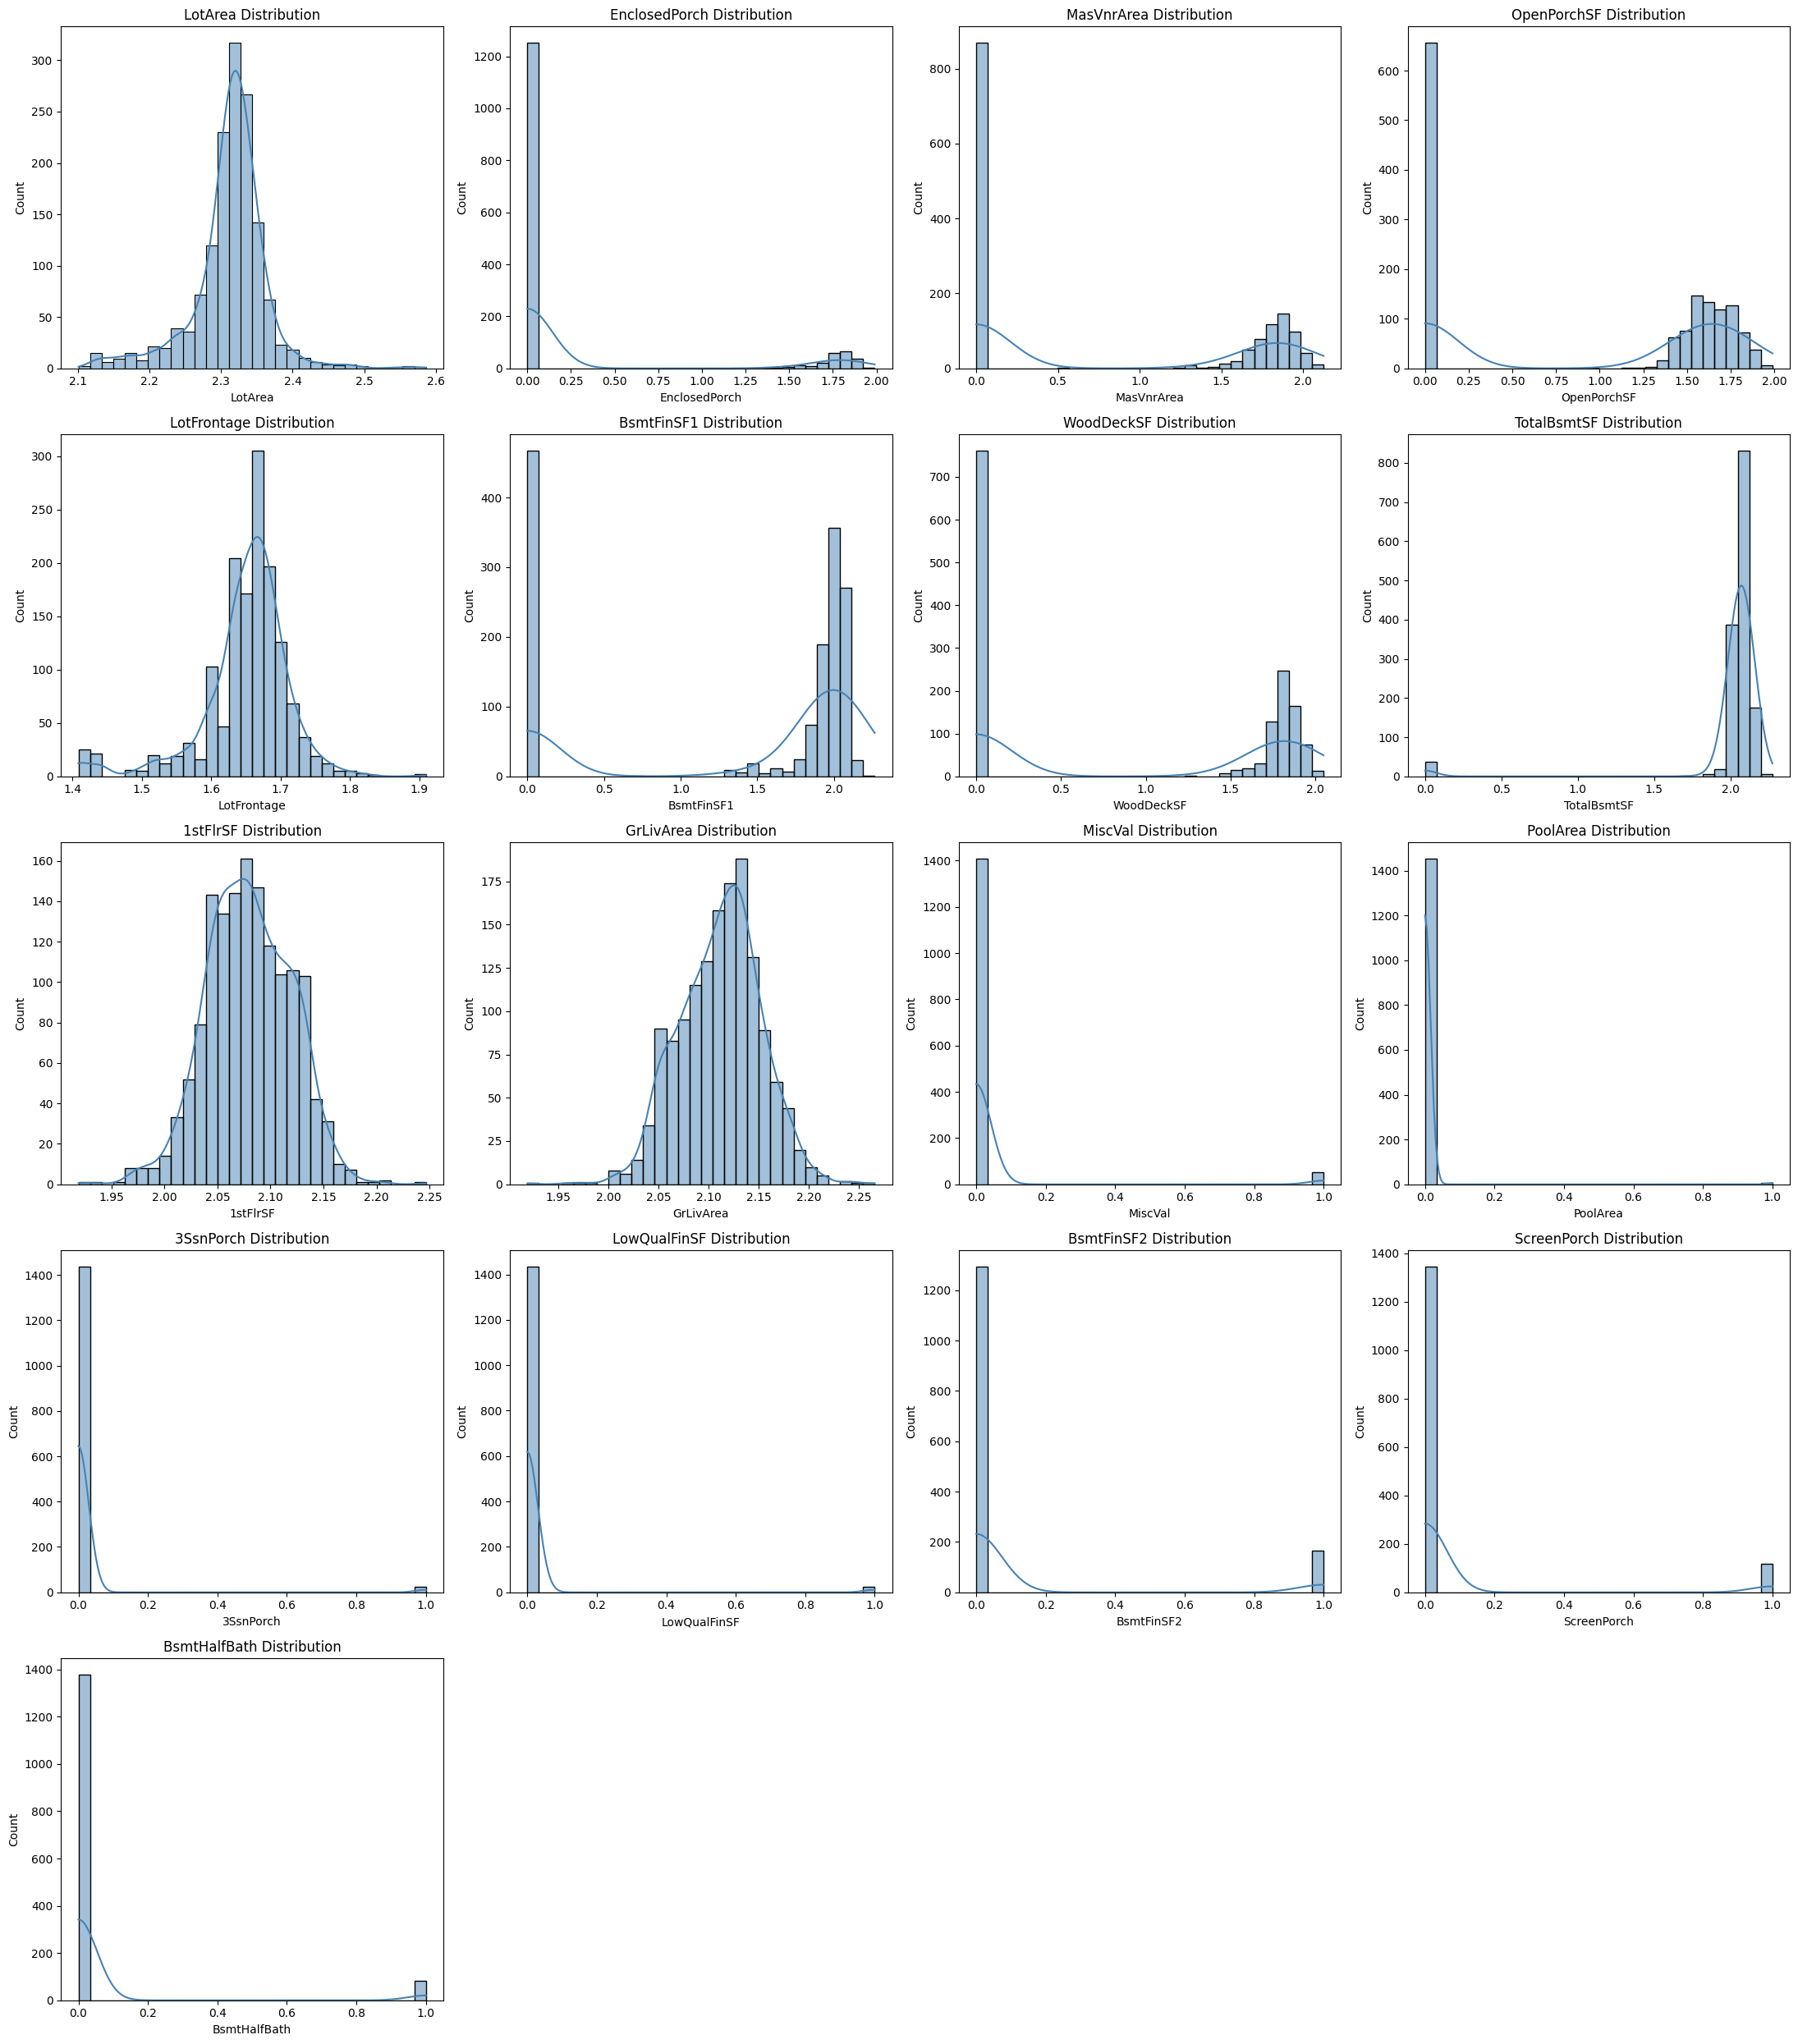

In [45]:
# distribution plot after log transformation and binary conversion
combined = log_features + binary_features

cols_per_row = 4
num_plots = len(combined)
rows = int(np.ceil(num_plots / cols_per_row))

plt.figure(figsize=(22, 5 * rows))

for i, col in enumerate(combined, 1):
    if col in train.columns:
        plt.subplot(rows, cols_per_row, i)
        sns.histplot(train[col].dropna(), kde=True, bins=30, color='steelblue')
        plt.title(f"{col} Distribution")
        plt.tight_layout()

plt.show()

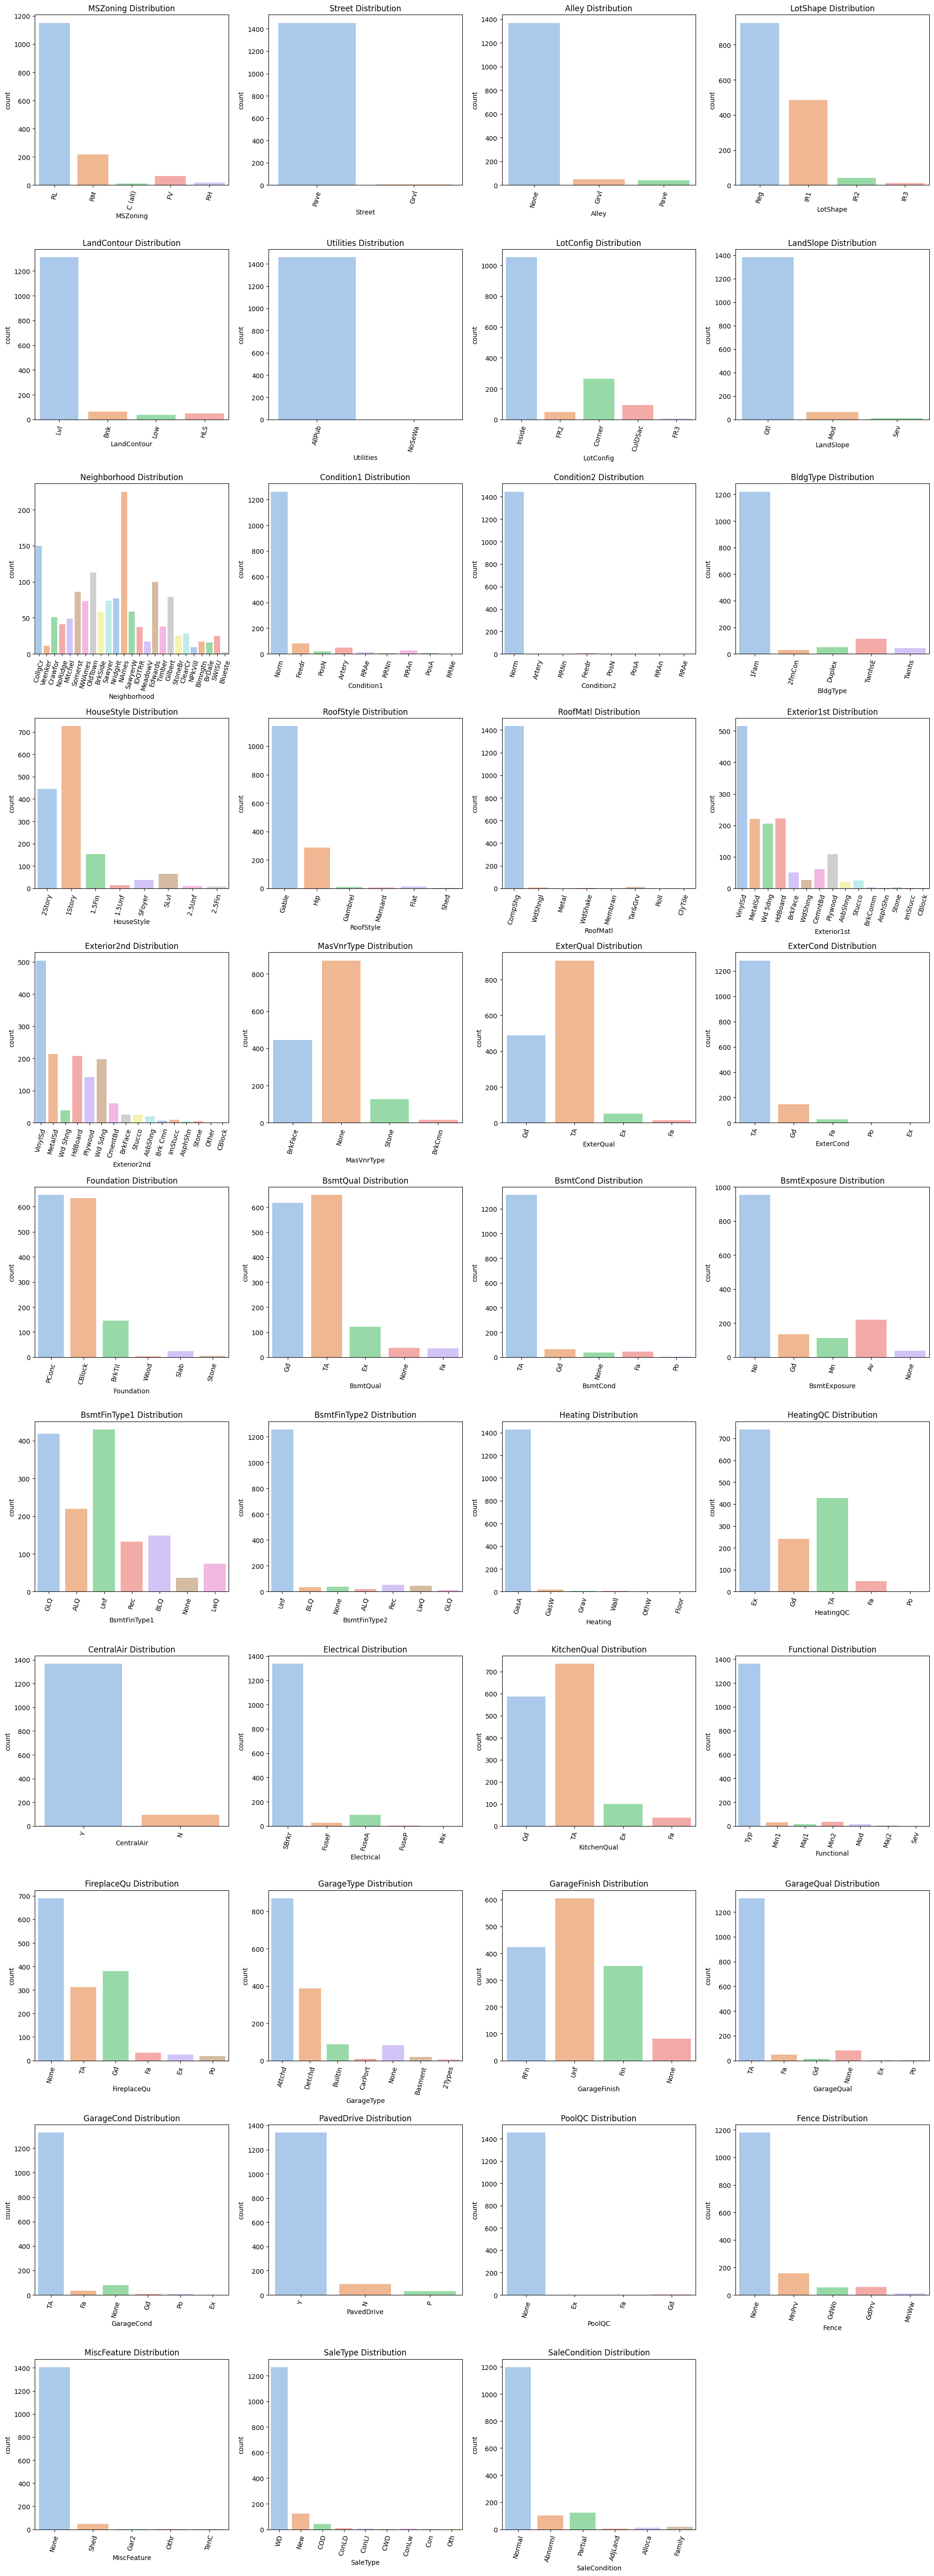

In [46]:
# categorical columns
cat_cols = train.select_dtypes(include=['object']).columns
cols_per_row = 4
num_plots = len(cat_cols)
rows = int(np.ceil(num_plots / cols_per_row))

plt.figure(figsize=(20, 5 * rows))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.countplot(data=train, x=col, hue=col, palette='pastel', legend=False)
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=75)
    plt.tight_layout()
plt.show()

The categorical feature distributions show clear patterns in housing preferences and construction norms within the dataset. Many categories are highly imbalanced, meaning certain building characteristics are far more common than others. For example, most homes are located in residential zones (MSZoning = RL) and are accessed by paved streets, reflecting typical suburban development patterns. Neighborhood distribution varies widely, with a few neighborhoods contributing a large share of homes, indicating potential location-driven pricing differences to be explored.

Quality-related categorical variables, such as Exterior, KitchenQual, BsmtQual, and ExterCond, show that most homes fall within average to good quality ranges, with extreme poor or excellent ratings being relatively rare. This suggests the housing stock is mostly mid-range in condition. Features such as PoolArea, 3SsnPorch, and certain garage attributes also display strong imbalance, where the majority of homes lack these amenities entirely. These features will likely require binary encoding or careful handling during modeling to avoid noise.

Overall, the categorical distributions highlight the importance of location, overall condition, and house style, while also signaling that many amenity features are sparsely represented. These imbalances indicate where feature simplification, grouping, or ordinal encoding will improve model interpretability and performance.

# Outlier handling

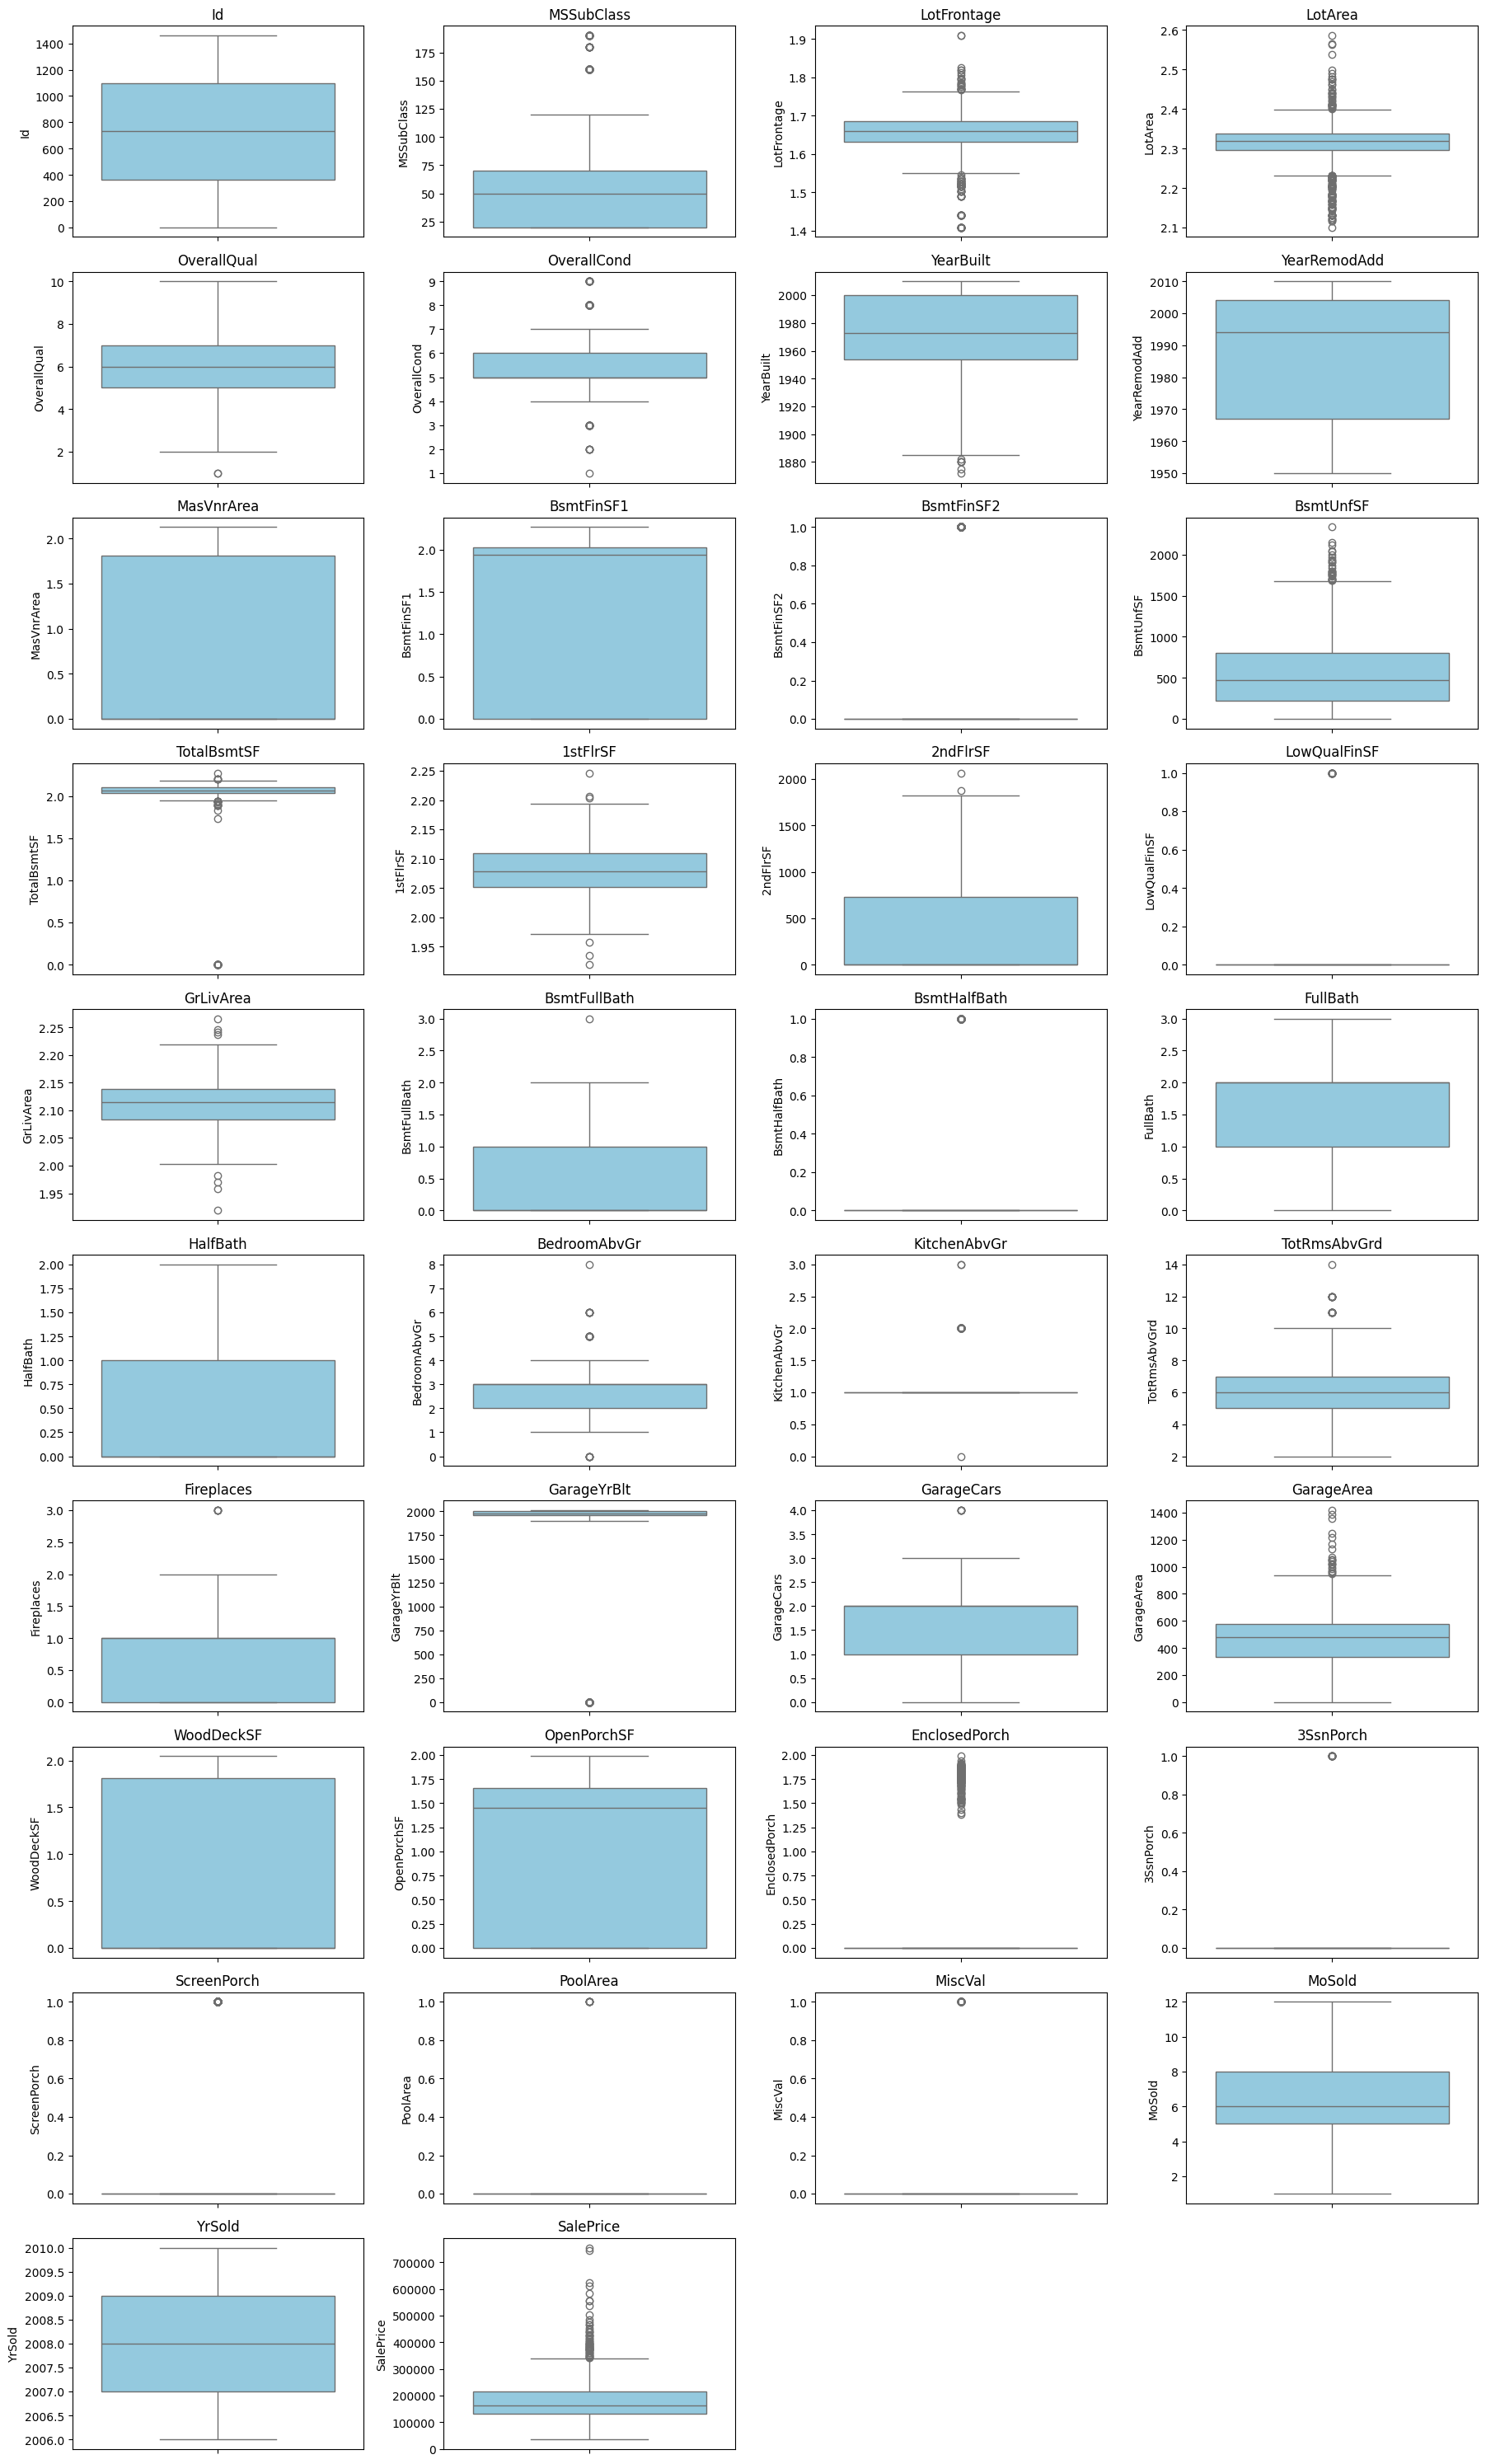

In [47]:
num_cols = train.select_dtypes(include=np.number).columns.tolist()

cols = 4
rows = math.ceil(len(num_cols) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=train[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [48]:
# GrLivArea
train = train[~((train['GrLivArea'] > 4500) & (train['SalePrice'] < 700000))]

# IQR removal
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    before = df.shape[0]
    df = df[(df[col] >= lower) & (df[col] <= upper)]
    after = df.shape[0]
    
    print(f"{col}: Removed {before - after} rows")
    return df

iqr_cols = [
    'LotArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF',
    '1stFlrSF', 'GrLivArea', 'GarageArea', 'TotalSF'
]

for col in iqr_cols:
    if col in train.columns:
        train = remove_outliers(train, col)

# Winsorize extreme features
cap_cols = ['WoodDeckSF', 'OpenPorchSF', 'MasVnrArea', 'BsmtFinSF2']

for col in cap_cols:
    if col in train.columns:
        upper_cap = train[col].quantile(0.99)
        train[col] = np.where(train[col] > upper_cap, upper_cap, train[col])

LotArea: Removed 139 rows
BsmtFinSF1: Removed 0 rows
BsmtUnfSF: Removed 30 rows
TotalBsmtSF: Removed 58 rows
1stFlrSF: Removed 2 rows
GrLivArea: Removed 3 rows
GarageArea: Removed 14 rows


Outliers were examined visually using boxplots and assessed statistically using the Interquartile Range (IQR) method. Several continuous variables displayed strong right-skew and extreme high values, particularly those related to property size such as LotArea, BsmtFinSF1, BsmtUnfSF, TotalBsmtSF, 1stFlrSF, GrLivArea, GarageArea, and the engineered TotalSF feature. Because extreme values in these features can distort model training and inflate error, we removed outliers falling beyond 1.5 × IQR for these variables. Additionally, we removed unusually large homes with very low sale prices in the GrLivArea feature. For variables with many zeros and a few extremely large values (e.g., MasVnrArea, WoodDeckSF, OpenPorchSF, BsmtFinSF2), we capped extreme values at the 99th percentile instead of removing observations, in order to preserve dataset size and maintain underlying distribution patterns. Overall, this balanced strategy ensures that the dataset remains representative while reducing the influence of extreme, non-typical values on model performance.

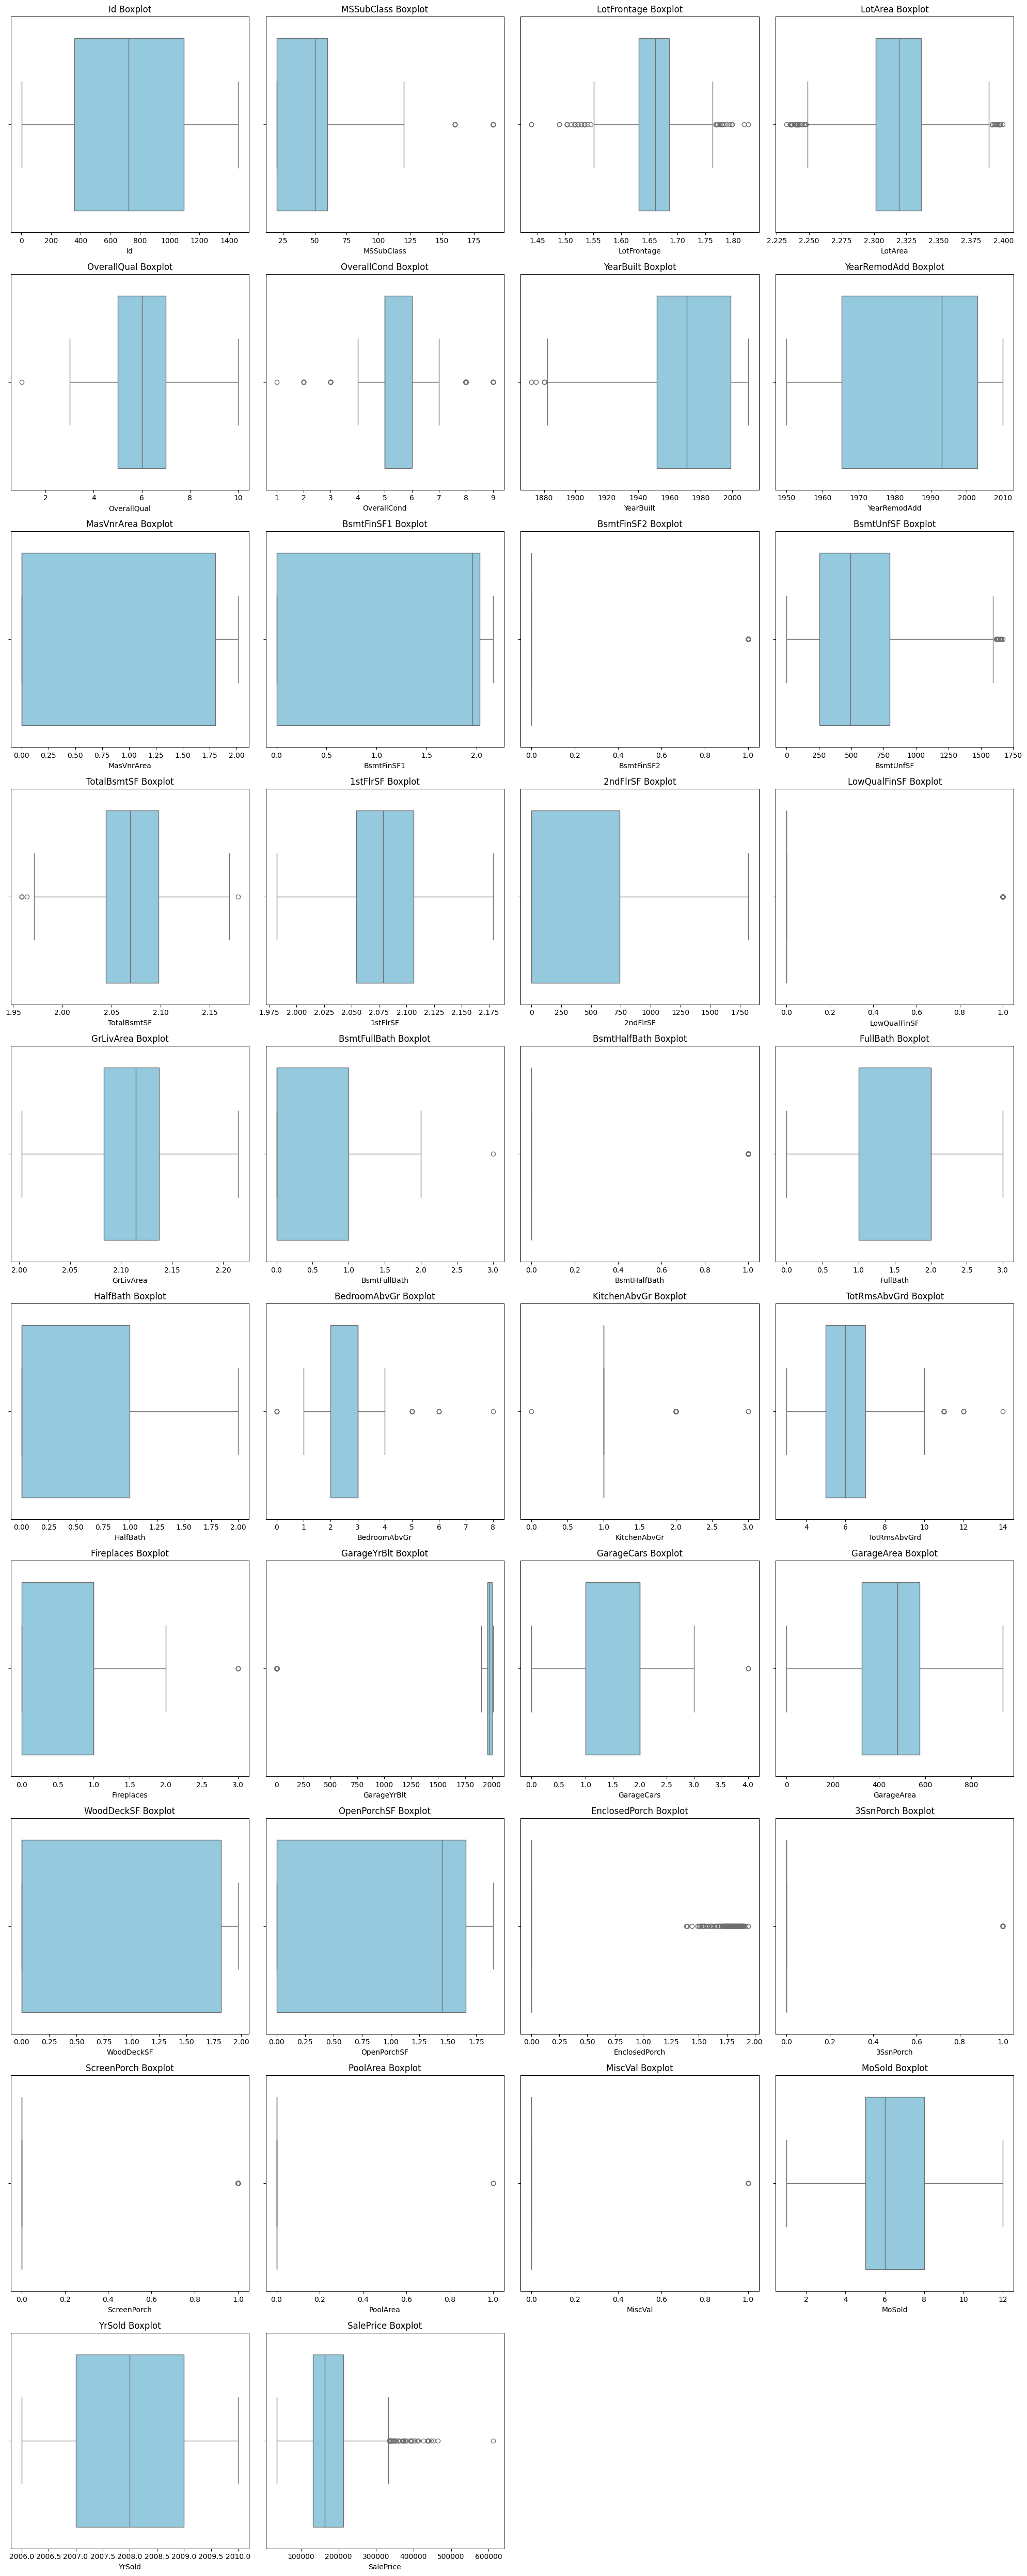

In [49]:
# boxplots after outlier handling
num_cols = train.select_dtypes(include=np.number).columns.tolist()

cols_per_row = 4
num_plots = len(num_cols)
rows = int(np.ceil(num_plots / cols_per_row))

plt.figure(figsize=(20, 5 * rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.boxplot(x=train[col], color="skyblue")
    plt.title(f"{col} Boxplot")
    plt.tight_layout()

plt.show()

## Biveriate analysis

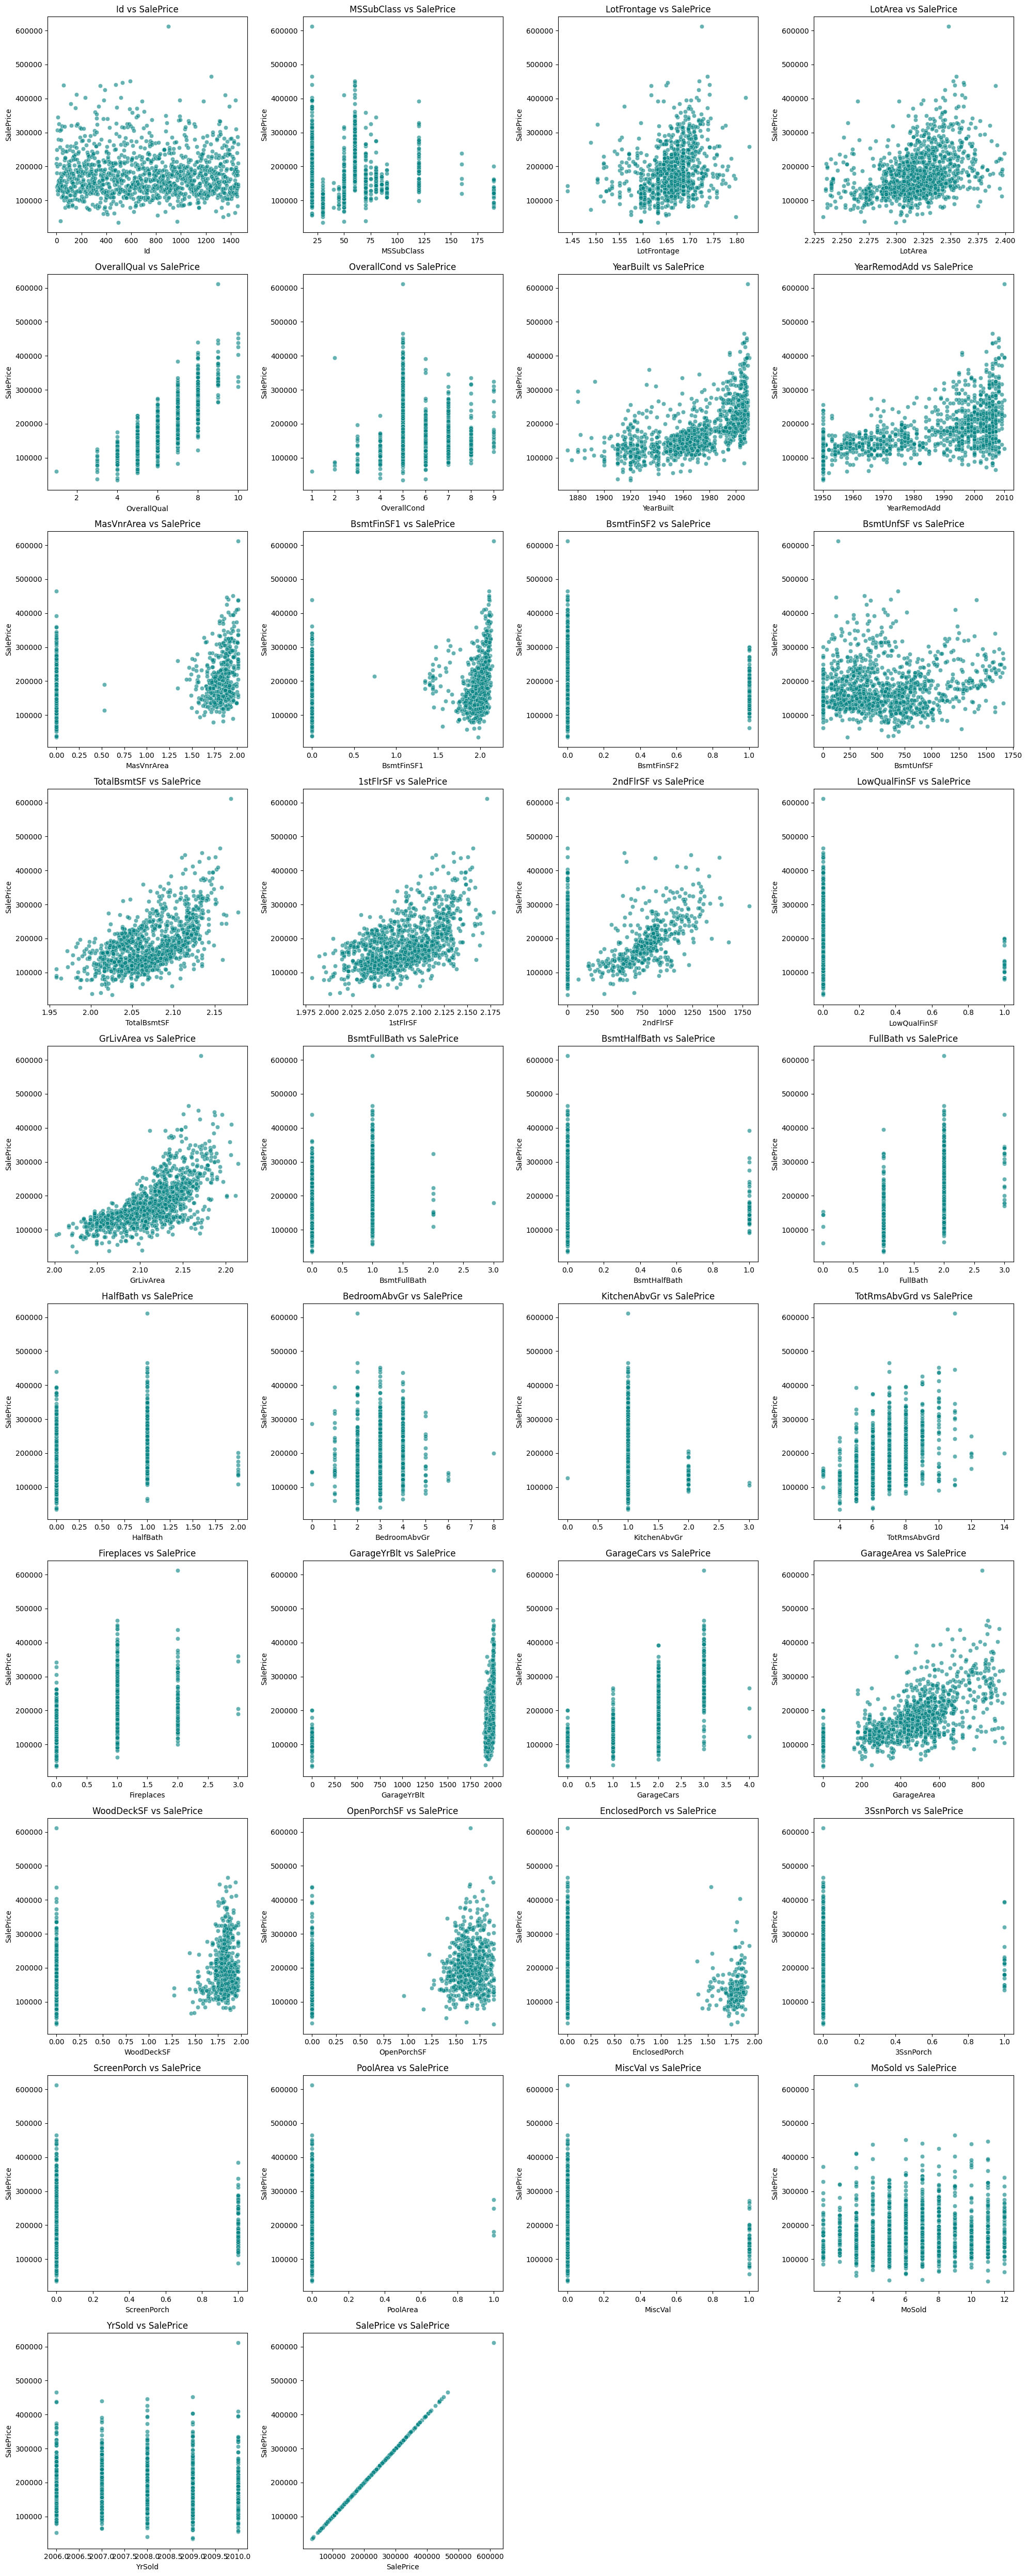

In [50]:
# Numerical vs Target
cols_per_row = 4
num_plots = len(num_cols)
rows = int(np.ceil(num_plots / cols_per_row))

plt.figure(figsize=(20, 5 * rows))
for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.scatterplot(data=train, x=col, y='SalePrice', color='teal', alpha=0.6)
    plt.title(f'{col} vs SalePrice')
plt.tight_layout()
plt.show()

The bivariate analysis shows clear and meaningful relationships between several numerical features and the sale price of homes. The strongest positive relationships appear with size and quality-related variables. GrLivArea, TotalBsmtSF, 1stFlrSF, and GarageArea show upward trends, indicating that larger homes and properties with more finished living space generally command higher prices. This aligns with real-world expectations: more usable area typically increases home value. However, the presence of a few extremely large houses introduces visible skew, reinforcing the importance of later applying log transformations to reduce the influence of these outliers during modeling.

OverallQual stands out as the most influential variable, displaying a noticeable step-like increase in price as quality ratings rise. This suggests that improvements in materials, craftsmanship, and finish levels significantly increase property value. YearBuilt and YearRemodAdd also show upward patterns, indicating that newer or recently renovated homes are more valuable, though the relationship is more moderate compared to quality and size.

Several variables such as PoolArea, 3SsnPorch, and MiscVal show almost no pattern with SalePrice due to the predominance of zeros, confirming that these features should be simplified to binary indicators. Bathroom counts and fireplaces show some positive price association but with weaker patterns compared to square footage and quality measures.

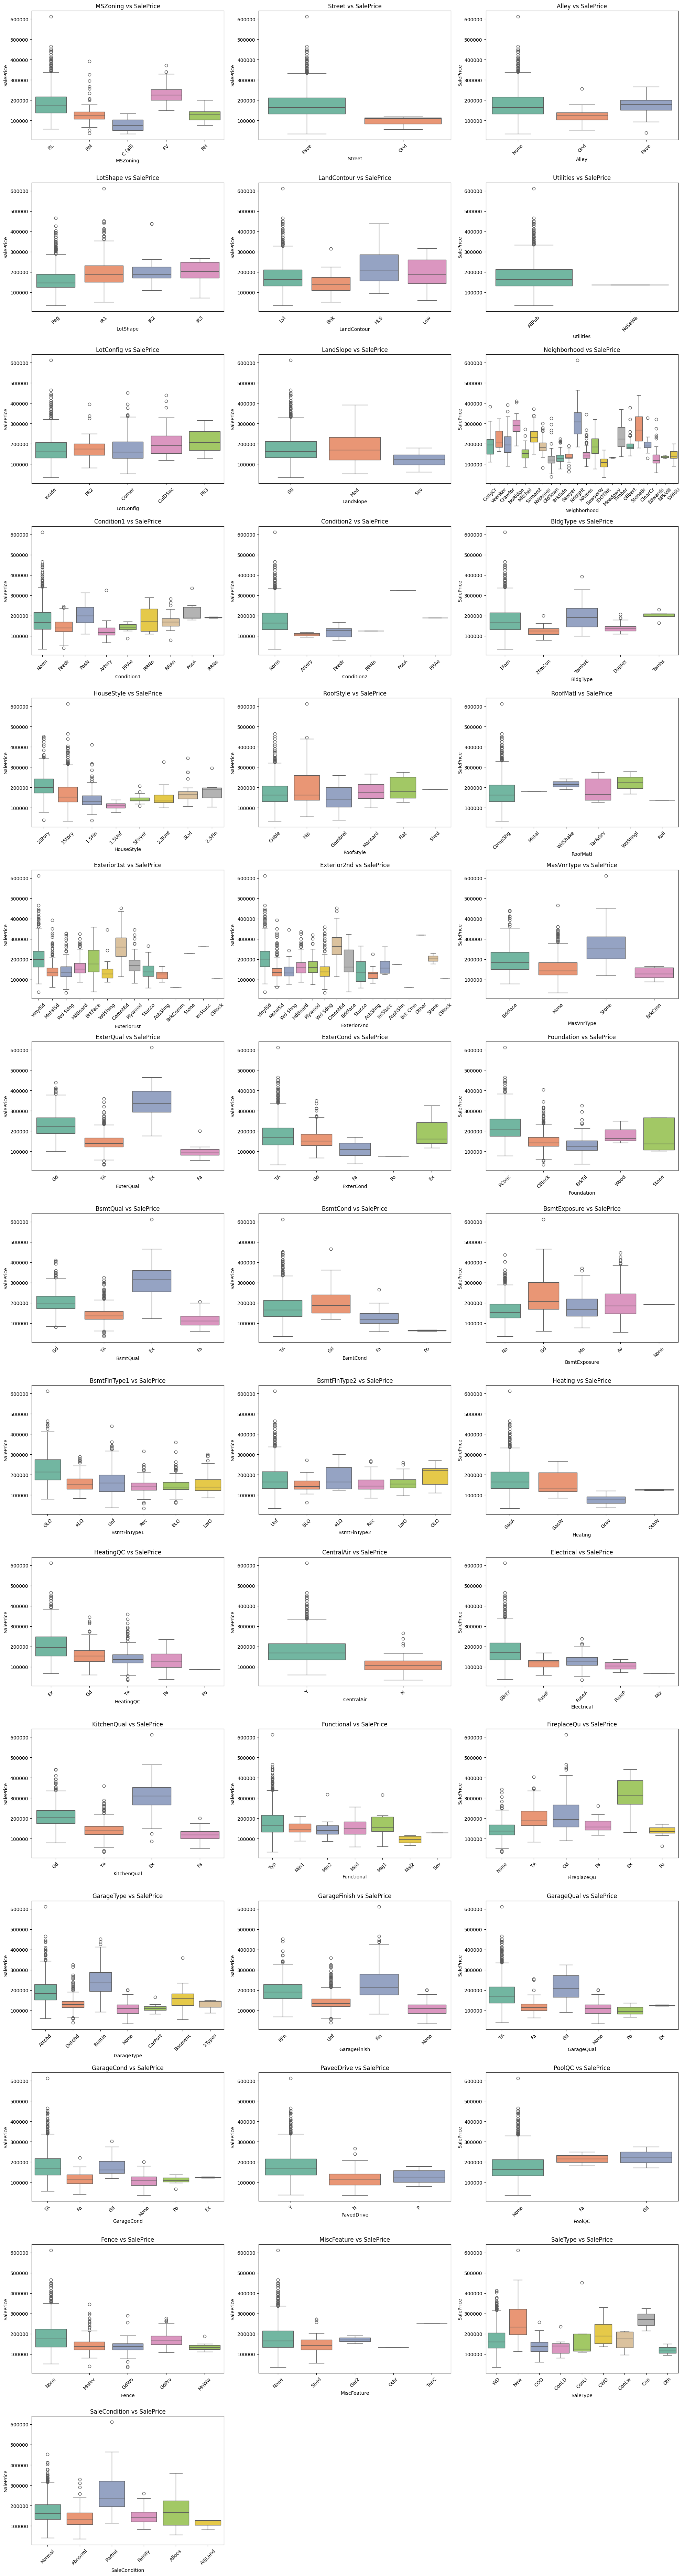

In [51]:
# categorical vs SalePrice
cols_per_row = 3
num_plots = len(cat_cols)
rows = int(np.ceil(num_plots / cols_per_row))

plt.figure(figsize=(20, 5 * rows))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.boxplot(data=train, x=col, y='SalePrice', hue=col, palette='Set2', legend=False)
    plt.title(f'{col} vs SalePrice')
    plt.xticks(rotation=45)
    plt.tight_layout()
plt.show()

The bivariate analysis of categorical features against SalePrice highlights several patterns in how structural quality, location, and property characteristics influence home values. Neighborhood stands out as one of the strongest categorical predictors of price, with certain areas such as *StoneBr*, *NridgHt*, and *NoRidge* consistently associated with significantly higher sale prices. This suggests a clear location-based premium in the housing market. Conversely, neighborhoods like *MeadowV* and *IDOTRR* show noticeably lower price ranges, indicating market segmentation by locality.

Quality-related categorical variables also show meaningful gradients. For instance, homes with higher KitchenQual and ExterQual ratings show higher SalePrice distributions. This supports the pattern observed earlier that material and finish quality strongly influence perceived and market value. Similarly, BsmtQual and GarageQual show a positive association with price, although the effect is less pronounced than for above-ground quality indicators.

Some categorical variables showed limited or no variation in relation to SalePrice. For example, Utilities and Street show almost no discriminatory power because nearly all homes share the same category. These features offer little value and can be removed to simplify the model without information loss. RoofStyle, Heating type, and Functional categories also showed only weak price differentiation, suggesting these features carry less predictive weight.

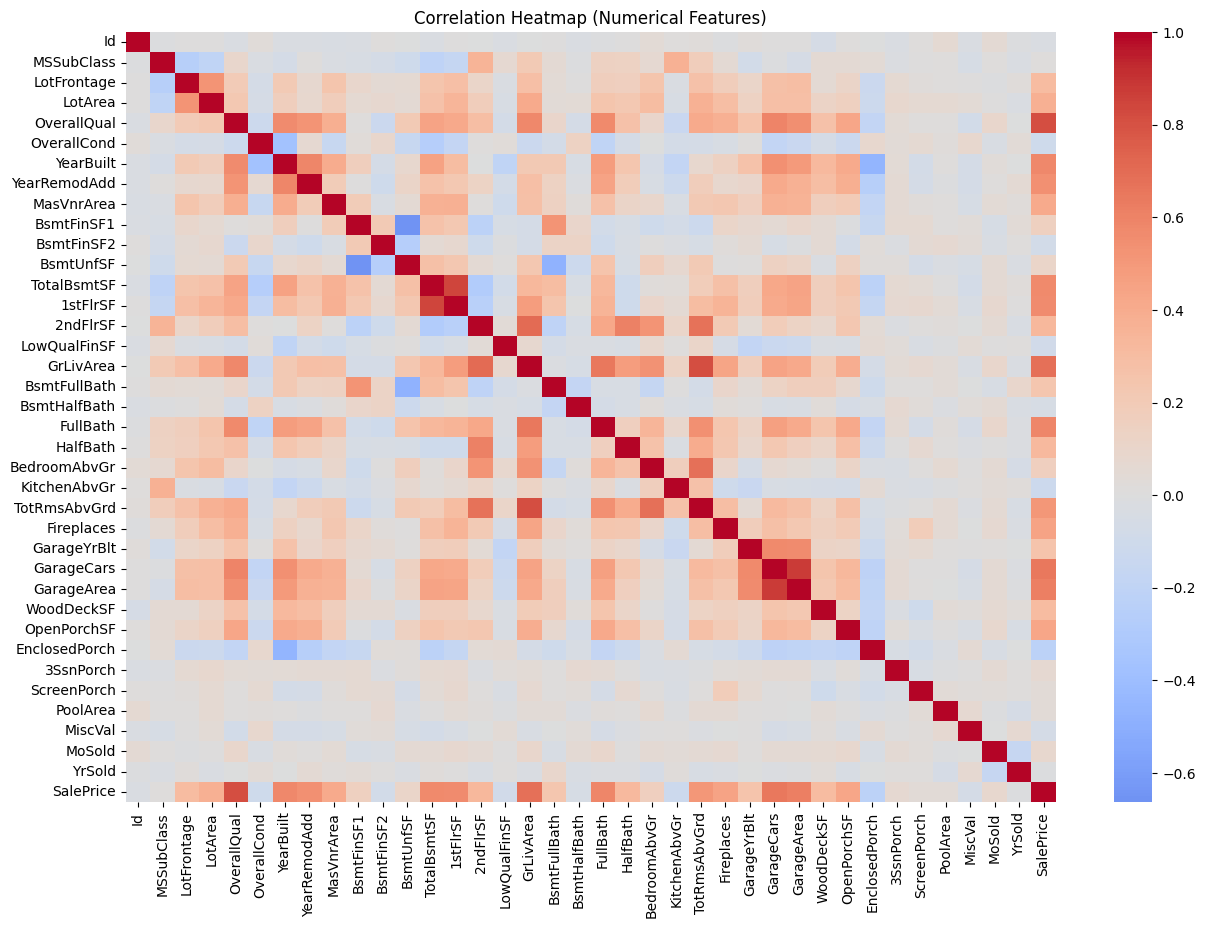

In [52]:
# correlation matrix
corr = train.corr(numeric_only=True)
plt.figure(figsize=(15, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Numerical Features)')
plt.show()

In [53]:
corr.SalePrice.sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.812412
GrLivArea        0.682658
GarageCars       0.649665
GarageArea       0.621810
FullBath         0.590284
YearBuilt        0.583369
TotalBsmtSF      0.571664
1stFlrSF         0.564421
YearRemodAdd     0.544131
TotRmsAbvGrd     0.508309
Fireplaces       0.445319
OpenPorchSF      0.431770
MasVnrArea       0.412526
LotArea          0.379326
2ndFlrSF         0.327199
HalfBath         0.323292
WoodDeckSF       0.307781
LotFrontage      0.307742
GarageYrBlt      0.257792
BsmtFullBath     0.233591
BedroomAbvGr     0.156078
BsmtFinSF1       0.151179
BsmtUnfSF        0.103648
MoSold           0.078758
3SsnPorch        0.069349
ScreenPorch      0.037334
PoolArea         0.033878
MSSubClass       0.017078
YrSold          -0.009443
Id              -0.029621
BsmtHalfBath    -0.051766
MiscVal         -0.071168
BsmtFinSF2      -0.082052
LowQualFinSF    -0.087887
OverallCond     -0.103290
KitchenAbvGr    -0.118637
EnclosedPorch   -0.223922
Name: SalePr

The correlation analysis shows that house quality and size are the strongest drivers of sale price. OverallQual has the highest positive correlation with SalePrice, followed by GrLivArea, GarageCars, GarageArea, TotalBsmtSF, and YearBuilt/YearRemodAdd, indicating that larger homes with better construction and more recent updates tend to sell for higher prices. Features such as KitchenAbvGr, LowQualFinSF, and EnclosedPorch show weak or negative correlations, suggesting they contribute little to price variation and may be less important in modeling. Additionally, several size-related features are strongly correlated with one another.

## Multivariate analysis

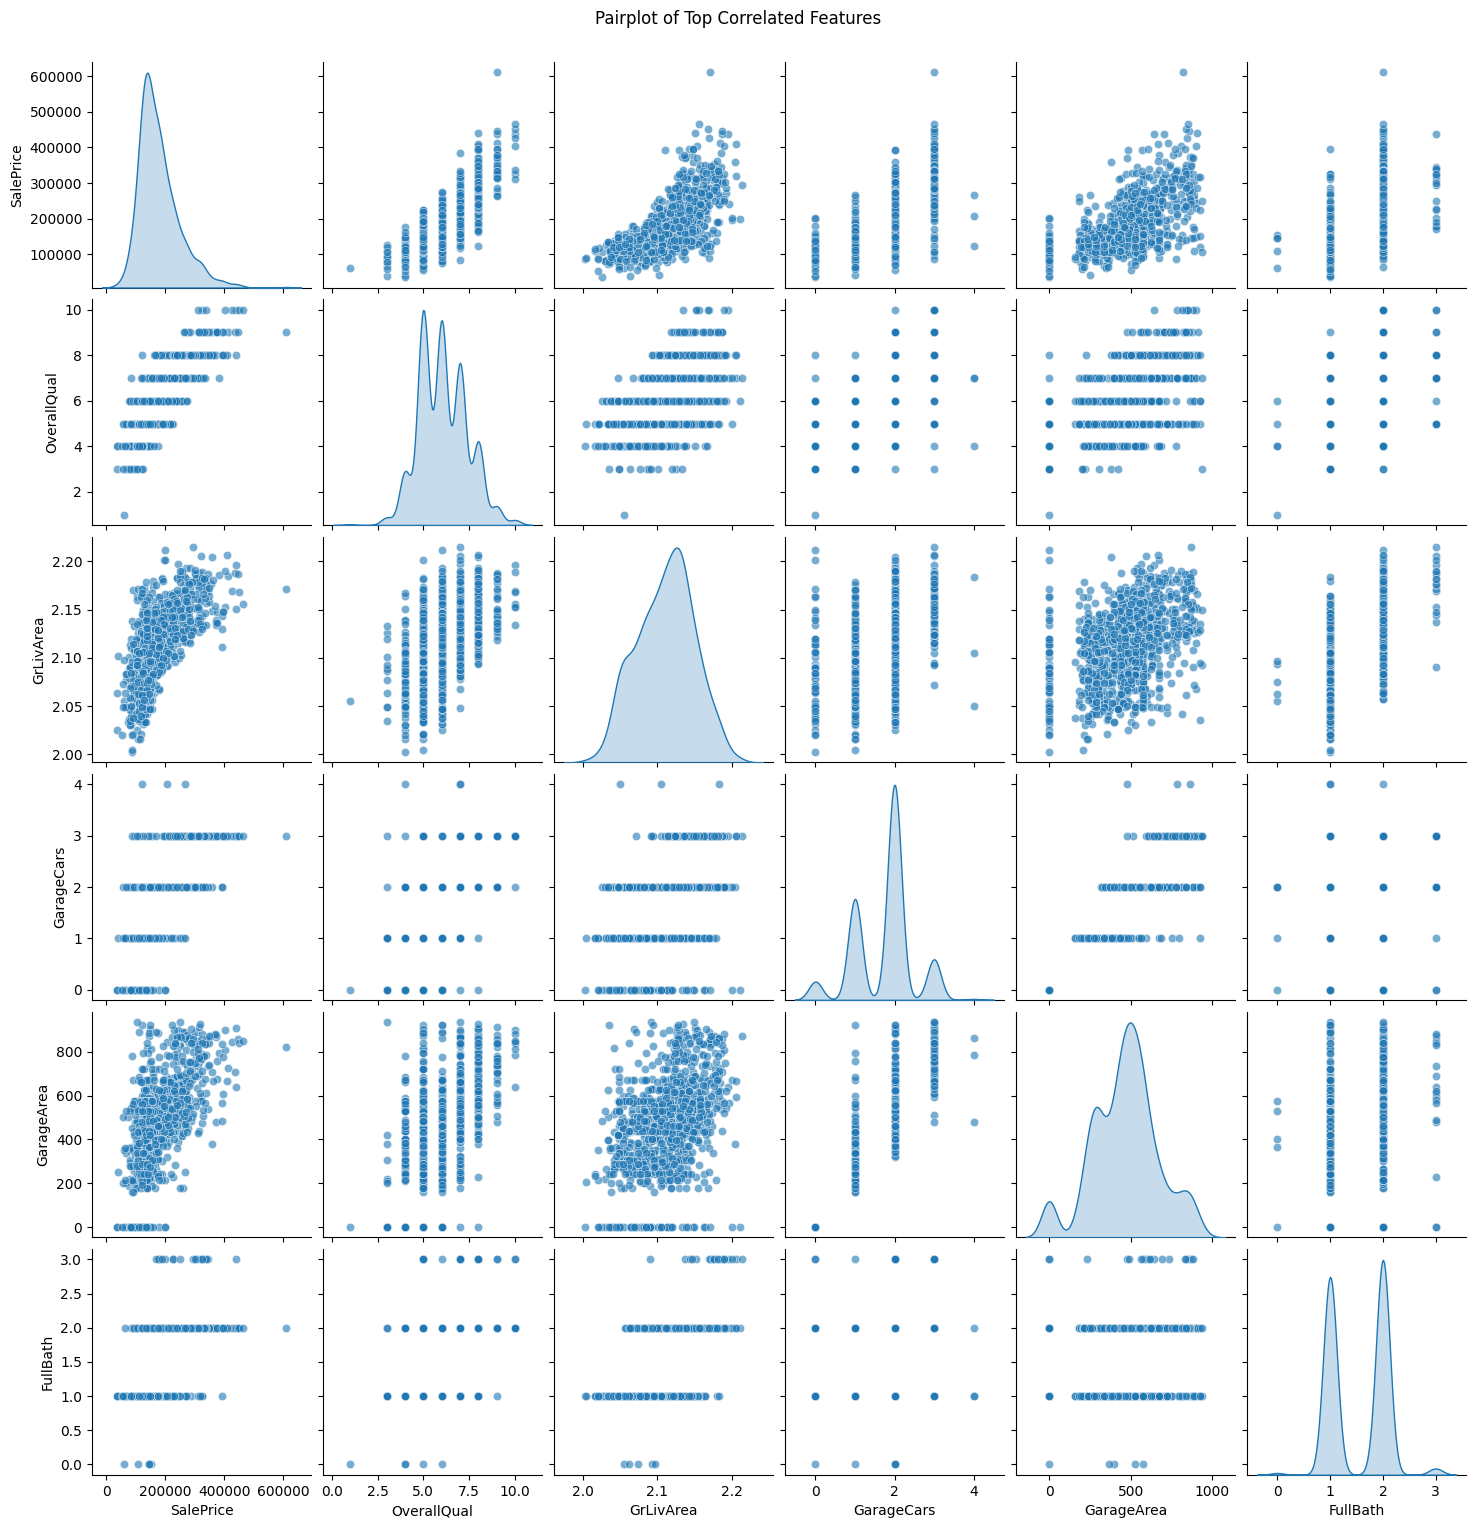

In [54]:
# Pairplot for top correlated numeric variables
corr_matrix = train.corr(numeric_only=True)

top_corr = corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(6).index

sns.pairplot(train[top_corr], diag_kind='kde', plot_kws={'alpha':0.6})
plt.suptitle('Pairplot of Top Correlated Features', y=1.02)
plt.show()

The pairplot of the top correlated features (OverallQual, GrLivArea, GarageCars, GarageArea, YearBuilt, and SalePrice) reveals several key interaction patterns. Homes with higher OverallQual and larger GrLivArea consistently show higher SalePrice, confirming that size and build quality jointly drive value. Garage capacity and garage size also increase with SalePrice but show diminishing returns beyond a 2-car garage. YearBuilt has a positive relationship with SalePrice, indicating that newer homes generally sell for more, but the effect is weaker than size and quality. The plot also highlights strong collinearity between GrLivArea, TotalBsmtSF/TotalSF, GarageCars, and GarageArea, suggesting that these size-related variables may need to be carefully selected or combined to avoid multicollinearity in modeling.

Neighborhood clearly impacts sale prices. Premium areas like NridgHt, NoRidge, and StoneBr have the highest values, while MeadowV and BrDale are the lowest. This confirms that location is a key driver of price, and we can encode it based on median SalePrice.

In [55]:
# Multicollinearity (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = train[['TotalBsmtSF','GrLivArea','GarageCars','GarageArea','OverallQual','YearBuilt']].assign(const=1)
vif = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
vif

,Feature,VIF
0,TotalBsmtSF,1.436533
1,GrLivArea,1.672276
2,GarageCars,5.094800
3,GarageArea,4.623906
4,OverallQual,2.347330
5,YearBuilt,1.846633
6,const,14871.421137


Moderate correlation exists among GarageCars, GarageArea, and TotalSF, but all VIF values are below 10. No severe multicollinearity detected.

## Encoding

In [56]:
# ORDINAL FEATURES & MAPPINGS
ordinal_mappings = {
    # Quality Ratings (Ex > Gd > TA > Fa > Po)
    "Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1,

    # Basement ratings include NA/NF
    "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "Ex": 5,
    "NA": 0, "None": 0, "NF": 0, "No": 0,

    # Exposure
    "Av": 3, "Mn": 2, "Gd": 4, "No": 1, "NA": 0, "None": 0, "NF": 0,

    # Functional
    "Typ": 7, "Min1": 6, "Min2": 5, "Mod": 4,
    "Maj1": 3, "Maj2": 2, "Sev": 1, "Sal": 0,

    # Pavement
    "Y": 2, "P": 1, "N": 0,

    # Fence
    "GdPrv": 4, "MnPrv": 3, "GdWo": 2, "MnWw": 1, "NA": 0,

    # Pool Quality
    "Ex": 4, "Gd": 3, "TA": 2, "Fa": 1, "NA": 0
}

ordinal_features = [
    # exterior + condition
    "ExterQual", "ExterCond",
    
    # basement qualities
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    
    # heating and kitchen
    "HeatingQC", "KitchenQual",
    
    # fireplace & garage quality
    "FireplaceQu",
    "GarageQual", "GarageCond", "GarageFinish",

    # functional + paved drive + fence + pool
    "Functional", "PavedDrive", "Fence", "PoolQC"
]

for col in ordinal_features:
    if col in train.columns:
        train[col] = train[col].fillna("NA").map(ordinal_mappings)

In [57]:
# One-Hot Encoding
one_hot_features = [
    "MSZoning", "LandContour", "LotConfig", "Neighborhood", "Condition1",
    "Condition2", "BldgType", "HouseStyle", "RoofStyle", "RoofMatl",
    "Exterior1st", "Exterior2nd", "MasVnrType", "Foundation", "Heating",
    "CentralAir", "Electrical", "GarageType", "MiscFeature", "SaleType",
    "SaleCondition", "Street", "Utilities", "LotShape", "LandSlope"
]

one_hot_features = [c for c in one_hot_features if c in train.columns]
train = pd.get_dummies(train, columns=one_hot_features, drop_first=True)

# Feature engineering

In [58]:
# Total Square Footage
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']

# Total Bathrooms
train['Total_Bathrooms'] = (train['FullBath'] + (0.5 * train['HalfBath']) +
                               train['BsmtFullBath'] + (0.5 * train['BsmtHalfBath']))

# House Age Features
train['RemodAge'] = train['YrSold'] - train['YearRemodAdd']
train['HouseAge'] = train['YrSold'] - train['YearBuilt']

# Quality × Size Interaction
train['OverallQualArea'] = train['OverallQual'] * train['TotalSF']
train["QualityScore"] = train["OverallQual"] * train["OverallCond"]
train["TotalPorch"] = train["OpenPorchSF"] + train["EnclosedPorch"] + train["ScreenPorch"] + train["3SsnPorch"]

# Feature selection

In [59]:
# Drop low-importance columns based on EDA findings
drop_cols = [
    'MiscVal', 'PoolArea', '3SsnPorch', 'LowQualFinSF', 'KitchenAbvGr',
    'MoSold', 'OverallCond', 'EnclosedPorch', 'ScreenPorch',
    'Fence', 'Alley', 'MiscFeature', 'Utilities'
]

train.drop(columns=drop_cols, inplace=True, errors='ignore')

In [60]:
train.to_csv("processed_train.csv", index=False)